# 19 — Exhaustive Single-Feature Sweep — Helpdesk

For a selected prefix, systematically substitute every possible value for each mutable
feature at each position, predict, and record the full probability vector.

No GA randomness — complete enumeration. Produces:
1. **Per-feature sensitivity heatmaps** — how each substitution destabilizes the prediction
2. **Top-K most impactful substitutions** — ranked by probability shift
3. **Prediction landscape per position** — how prediction distribution changes across values

In [1]:
import sys
import os
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import torch
import numpy as np
import pandas as pd

# --- Load dataset + prediction model ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
full_dataset = torch.load(data_path, weights_only=False)
dataset = full_dataset

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

model_path = _current / 'src' / 'notebooks' / 'training_variational_dropout' / 'Helpdesk' / 'Helpdesk_full_grad_norm_new_4layer.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(model_path), dropout=0.0)
model.eval()
print(f'Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters')

# --- TensorDecoder + activity vocabulary ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(full_dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')

# --- Predictor for batch inference ---
from src.interpretability.perturbation_methods import RevisedPlusModelPredictor

predictor = RevisedPlusModelPredictor(model, suffix_step=0, activity_feature=ACTIVITY_FEATURE)
print('Predictor ready')

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Dataset: 6077 sequences, 12 cat, 4 num, seq_len=18
Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('VariantIndex', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


Predictor ready


## Sweep Configuration

In [3]:
# Mutable categorical feature indices
MUTABLE_CAT_INDICES = [0, 1, 2]        # Activity, Resource, Variant index
CASE_LEVEL_CAT_INDICES = [2]            # Variant index: constant across all positions

# Build valid values for each mutable feature (exclude padding=0)
vocab_sizes = decoder.get_vocab_sizes()
valid_values = {}
for ci in MUTABLE_CAT_INDICES:
    feat_name = decoder.cat_features[ci]
    valid_values[ci] = list(range(1, vocab_sizes[ci]))  # 1..vocab_size-1 (skip padding)
    print(f'  Feature {ci} ({feat_name}): {len(valid_values[ci])} valid values')

print(f'\nTotal mutable features: {len(MUTABLE_CAT_INDICES)}')

  Feature 0 (Activity): 15 valid values
  Feature 1 (Resource): 23 valid values
  Feature 2 (Variant index): 174 valid values

Total mutable features: 3


## Prefix Selection

In [4]:
# === Scan dataset for candidate sequences ===
N_CANDIDATES = 50
scan_limit = min(500, len(dataset))

candidates = []
seen_cases = set()
for i in range(scan_limit):
    cat_t, num_t, case_id = dataset[i]
    act = cat_t[0]

    if case_id in seen_cases:
        continue
    seen_cases.add(case_id)

    trace_len = int((act != 0).sum().item())
    act_seq = [activity_names[a.item()] for a in act if a.item() != 0]

    candidates.append({
        'dataset_idx': i,
        'case_id': case_id,
        'trace_len': trace_len,
        'activities': ' -> '.join(act_seq),
    })

    if len(candidates) >= N_CANDIDATES:
        break

df_candidates = pd.DataFrame(candidates)
print(f'Found {len(candidates)} unique cases (scanned {scan_limit})')
print('Set SELECTED_ROW and PREFIX_LEN below.\n')
display(df_candidates)

Found 50 unique cases (scanned 500)
Set SELECTED_ROW and PREFIX_LEN below.



,dataset_idx,case_id,trace_len,activities
0,0,Case 1016,5,Assign seriousness -> Take in charge ticket ->...
1,6,Case 102,5,Assign seriousness -> Take in charge ticket ->...
2,12,Case 1032,5,Assign seriousness -> Take in charge ticket ->...
3,19,Case 1034,5,Assign seriousness -> Take in charge ticket ->...
4,25,Case 1039,5,Assign seriousness -> Take in charge ticket ->...
5,31,Case 1040,5,Assign seriousness -> Take in charge ticket ->...
6,37,Case 105,5,Assign seriousness -> Take in charge ticket ->...
7,44,Case 1058,5,Assign seriousness -> Take in charge ticket ->...
8,51,Case 1061,5,Assign seriousness -> Assign seriousness -> Ta...
9,59,Case 1066,5,Assign seriousness -> Take in charge ticket ->...


In [5]:
# ============================================
# SELECT A CASE AND PREFIX LENGTH
# ============================================
SELECTED_ROW = 0   # row index in the candidates table above
PREFIX_LEN = 3     # how many events to use as prefix (1 .. trace_len)

# --- Load and truncate to prefix ---
selected = df_candidates.iloc[SELECTED_ROW]
test_idx = selected['dataset_idx']
trace_len = selected['trace_len']
cat_tuple_full, num_tuple_full, case_id = dataset[test_idx]

prefix_len = max(1, min(PREFIX_LEN, trace_len))
if prefix_len != PREFIX_LEN:
    print(f'Note: PREFIX_LEN clamped to {prefix_len} (trace has {trace_len} events)')

# Build left-padded prefix tensors
pad_len = seq_len - prefix_len
cat_tuple = []
for c in cat_tuple_full:
    t = torch.zeros_like(c)
    src_start = seq_len - trace_len
    t[pad_len:] = c[src_start:src_start + prefix_len]
    cat_tuple.append(t)
cat_tuple = tuple(cat_tuple)

num_tuple = []
for n in num_tuple_full:
    t = torch.zeros_like(n)
    src_start = seq_len - trace_len
    t[pad_len:] = n[src_start:src_start + prefix_len]
    num_tuple.append(t)
num_tuple = tuple(num_tuple)

# Show original prediction
cat_in = [c.unsqueeze(0) for c in cat_tuple]
num_in = [n.unsqueeze(0) for n in num_tuple]
with torch.no_grad():
    preds = model((cat_in, num_in))[0]
    logits = preds[0][f'{ACTIVITY_FEATURE}_mean'][0]
    p = torch.softmax(logits, dim=-1)
    top_p, top_idx = p.max(dim=-1)

original_pred_idx = top_idx.item()
original_pred_name = activity_names[original_pred_idx]
original_pred_prob = top_p.item()
original_probs = p.numpy()

prefix_acts = [activity_names[cat_tuple[0][j].item()] for j in range(pad_len, seq_len)]
print(f'Case: {case_id}')
print(f'Prefix ({prefix_len}/{trace_len}): {" -> ".join(prefix_acts)}')
print(f'Predicted next: {original_pred_name} (p={original_pred_prob:.3f})')
print()
df_orig = decoder.decode_sequence(cat_tuple, num_tuple, case_id=case_id)
display(df_orig)

Case: Case 1016
Prefix (3/5): Assign seriousness -> Take in charge ticket -> Resolve ticket
Predicted next: Closed (p=0.911)



,Activity,Resource,Variant index,seriousness,customer,product,responsible_section,seriousness_2,service_level,service_type,support_section,workgroup,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,Case ID
0,Assign seriousness,Value 8,1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 2,0.0,963303.3125,2.0,27781.000000,Case 1016
1,Take in charge ticket,Value 8,1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 2,149.0,148.9375,2.0,27930.000000,Case 1016
2,Resolve ticket,Value 16,1.0,Value 1,Value 8,Value 3,Value 1,Value 2,Value 2,Value 2,Value 1,Value 2,26072.0,25923.0000,2.0,53852.996094,Case 1016


## Exhaustive Feature Sweep

For each mutable feature, at each position, try every valid value and record the prediction.

In [6]:
import time

# Prepare frozen tensors
frozen_cat = [c.clone() for c in cat_tuple]   # List of [seq_len] tensors
frozen_num_stacked = torch.stack(list(num_tuple), dim=-1)  # [seq_len, n_num]

sweep_results = []  # List of dicts
t0 = time.time()

for ci in MUTABLE_CAT_INDICES:
    feat_name = decoder.cat_features[ci]
    is_case_level = ci in CASE_LEVEL_CAT_INDICES
    vals = valid_values[ci]
    N = len(vals)

    # For case-level features, position doesn't matter — sweep once
    positions = [0] if is_case_level else list(range(prefix_len))

    for pos_idx in positions:
        pos = pad_len + pos_idx

        # Build batch: N variants, one per valid value
        cat_batch = []
        for cj in range(n_cat):
            if cj == ci:
                t = frozen_cat[cj].unsqueeze(0).expand(N, -1).clone()
                for k, val in enumerate(vals):
                    if is_case_level:
                        # Set all non-padding positions to val
                        t[k, pad_len:] = val
                    else:
                        t[k, pos] = val
                cat_batch.append(t)
            else:
                cat_batch.append(frozen_cat[cj].unsqueeze(0).expand(N, -1).clone())

        num_stacked = frozen_num_stacked.unsqueeze(0).expand(N, -1, -1).clone()

        # Batch predict
        preds_batch, probs_batch = predictor.predict_batch(cat_batch, num_stacked)

        # Record results
        original_val = frozen_cat[ci][pos].item()
        for k, val in enumerate(vals):
            pred_class = int(preds_batch[k])
            sweep_results.append({
                'feature': feat_name,
                'feature_idx': ci,
                'position': pos_idx + 1,  # 1-indexed
                'is_case_level': is_case_level,
                'value_idx': val,
                'value_name': decoder.decode_categorical_value(ci, val),
                'is_original': val == original_val,
                'predicted_class': pred_class,
                'predicted_class_name': activity_names[pred_class],
                'prob_original_class': float(probs_batch[k, original_pred_idx]),
                'prob_predicted_class': float(probs_batch[k, pred_class]),
                'probability_vector': probs_batch[k].tolist(),
            })

elapsed = time.time() - t0
df_sweep = pd.DataFrame(sweep_results)
print(f'Sweep complete: {len(df_sweep)} predictions in {elapsed:.2f}s')
print(f'  Features swept: {df_sweep["feature"].nunique()}')
print(f'  Prediction flips: {(~df_sweep["is_original"] & (df_sweep["predicted_class"] != original_pred_idx)).sum()}')

Sweep complete: 288 predictions in 0.42s
  Features swept: 3
  Prediction flips: 99


## Visualization 1: Per-Feature Sensitivity Heatmaps

For each mutable feature, a heatmap showing how each value substitution affects
the probability of the original predicted class. The original value is marked with a star.

DEBUG:matplotlib:CACHEDIR=/Users/philippeichhorn/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/philippeichhorn/.matplotlib/fontlist-v390.json
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix

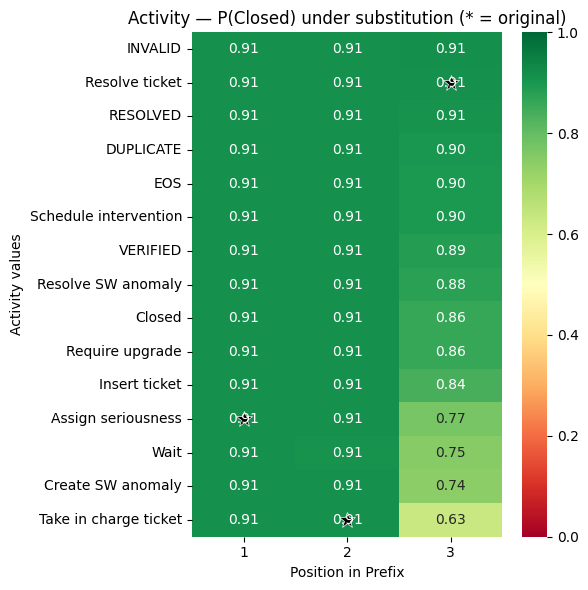

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x315d41be0>


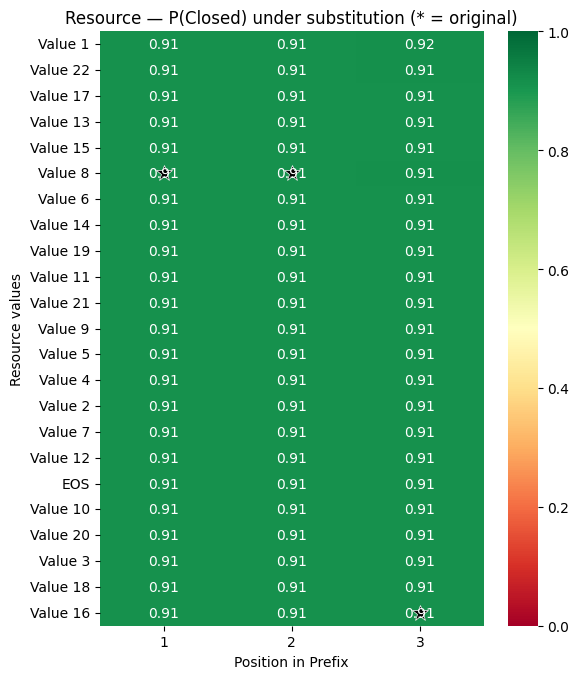

DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=7.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymBol.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U

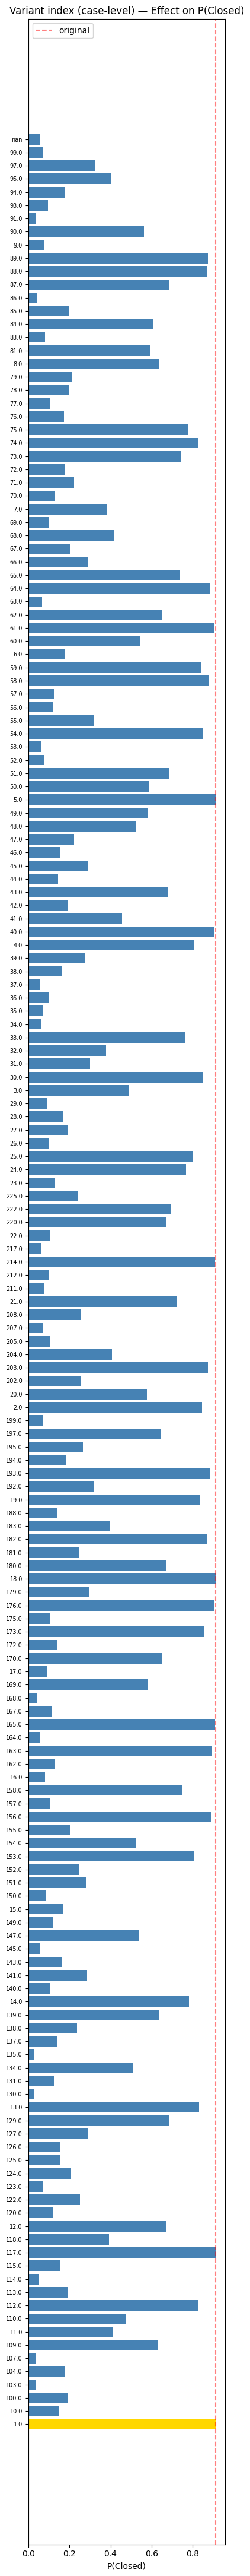

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

for ci in MUTABLE_CAT_INDICES:
    feat_name = decoder.cat_features[ci]
    is_case_level = ci in CASE_LEVEL_CAT_INDICES
    df_feat = df_sweep[df_sweep['feature_idx'] == ci].copy()

    if is_case_level:
        # Single column: just show prob_original_class per value
        df_feat = df_feat.sort_values('value_idx')
        fig, ax = plt.subplots(figsize=(4, max(6, len(df_feat) * 0.25)))

        colors = ['gold' if row['is_original'] else 'steelblue'
                  for _, row in df_feat.iterrows()]
        ax.barh(range(len(df_feat)), df_feat['prob_original_class'], color=colors)
        ax.set_yticks(range(len(df_feat)))
        ax.set_yticklabels(df_feat['value_name'], fontsize=7)
        ax.set_xlabel(f'P({original_pred_name})')
        ax.set_title(f'{feat_name} (case-level) — Effect on P({original_pred_name})')
        ax.axvline(x=original_pred_prob, color='red', linestyle='--', alpha=0.5, label='original')
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        # Heatmap: X=position, Y=value, color=prob_original_class
        pivot = df_feat.pivot(index='value_name', columns='position', values='prob_original_class')

        # Sort by mean impact
        pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

        fig, ax = plt.subplots(figsize=(max(6, prefix_len * 2), max(6, len(pivot) * 0.3)))
        sns.heatmap(
            pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax,
            xticklabels=True, yticklabels=True,
        )

        # Mark original values
        orig_rows = df_feat[df_feat['is_original']]
        for _, row in orig_rows.iterrows():
            y_idx = list(pivot.index).index(row['value_name'])
            x_idx = list(pivot.columns).index(row['position'])
            ax.plot(x_idx + 0.5, y_idx + 0.5, marker='*', color='black',
                    markersize=12, markeredgecolor='white', markeredgewidth=0.5)

        ax.set_xlabel('Position in Prefix')
        ax.set_ylabel(f'{feat_name} values')
        ax.set_title(f'{feat_name} — P({original_pred_name}) under substitution (* = original)')
        plt.tight_layout()
        plt.show()

## Visualization 2: Top-K Most Impactful Substitutions

Across all features and positions, rank substitutions by the magnitude of
probability shift on the original predicted class.

In [8]:
TOP_K = 20

# Compute probability shift for non-original values
df_impact = df_sweep[~df_sweep['is_original']].copy()
df_impact['prob_shift'] = df_impact['prob_original_class'] - original_pred_prob
df_impact['abs_prob_shift'] = df_impact['prob_shift'].abs()

# Get original value names for context
orig_value_names = {}
for ci in MUTABLE_CAT_INDICES:
    feat_name = decoder.cat_features[ci]
    is_case_level = ci in CASE_LEVEL_CAT_INDICES
    for pos_idx in range(prefix_len):
        pos = pad_len + pos_idx
        orig_val = frozen_cat[ci][pos].item()
        key = (feat_name, pos_idx + 1)
        orig_value_names[key] = decoder.decode_categorical_value(ci, orig_val)

# Top-K by largest absolute shift
top_k = df_impact.nlargest(TOP_K, 'abs_prob_shift')

display_rows = []
for _, row in top_k.iterrows():
    key = (row['feature'], row['position'])
    display_rows.append({
        'Feature': row['feature'],
        'Position': row['position'],
        'Original Value': orig_value_names.get(key, '?'),
        'Substituted Value': row['value_name'],
        f'P({original_pred_name}) before': f'{original_pred_prob:.3f}',
        f'P({original_pred_name}) after': f'{row["prob_original_class"]:.3f}',
        'Shift': f'{row["prob_shift"]:+.3f}',
        'New Prediction': row['predicted_class_name'],
    })

df_top_k = pd.DataFrame(display_rows)
print(f'Top {TOP_K} most impactful substitutions (by |shift| on P({original_pred_name})):')
display(df_top_k)

Top 20 most impactful substitutions (by |shift| on P(Closed)):


,Feature,Position,Original Value,Substituted Value,P(Closed) before,P(Closed) after,Shift,New Prediction
0,Variant index,1,1.0,130.0,0.911,0.028,-0.883,Take in charge ticket
1,Variant index,1,1.0,135.0,0.911,0.030,-0.881,Take in charge ticket
2,Variant index,1,1.0,91.0,0.911,0.038,-0.874,Take in charge ticket
3,Variant index,1,1.0,103.0,0.911,0.038,-0.874,Take in charge ticket
4,Variant index,1,1.0,107.0,0.911,0.040,-0.871,Take in charge ticket
5,Variant index,1,1.0,168.0,0.911,0.043,-0.868,Take in charge ticket
6,Variant index,1,1.0,86.0,0.911,0.044,-0.867,Take in charge ticket
7,Variant index,1,1.0,114.0,0.911,0.050,-0.861,Resolve ticket
8,Variant index,1,1.0,164.0,0.911,0.056,-0.855,Resolve ticket
9,Variant index,1,1.0,NaN,0.911,0.058,-0.854,Resolve ticket


## Visualization 3: Prediction Landscape per Position

For each position, show how the prediction distribution changes across feature values.
One subplot per mutable event-level feature and position.

DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=6.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizFourSymBol.ttf', name='STIXSizeFourSym', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U

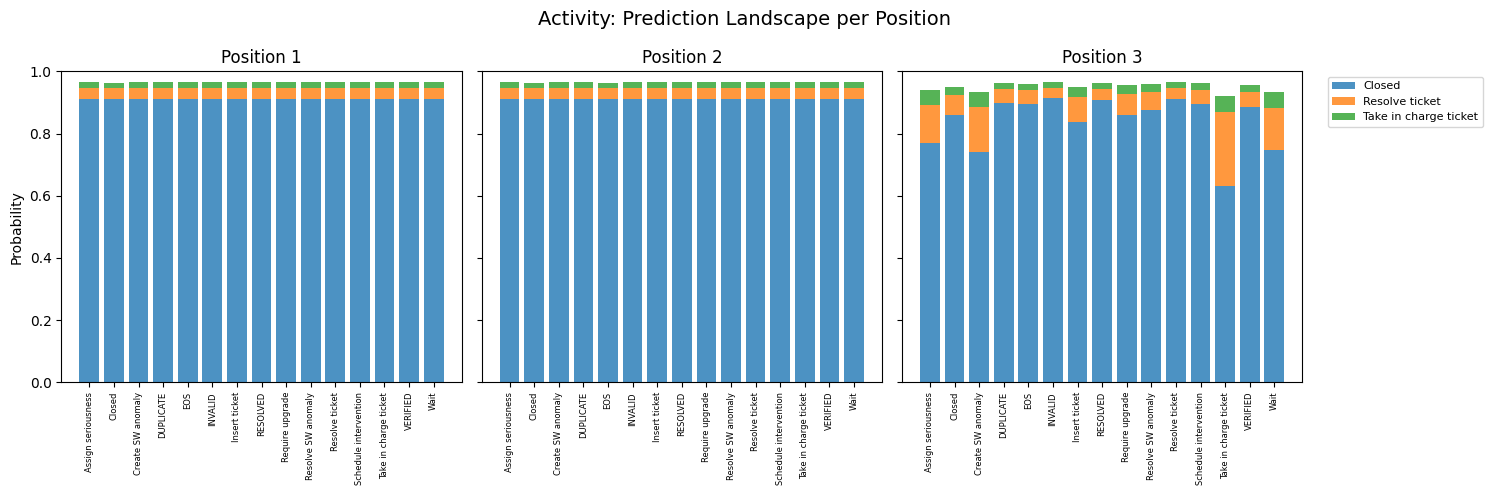

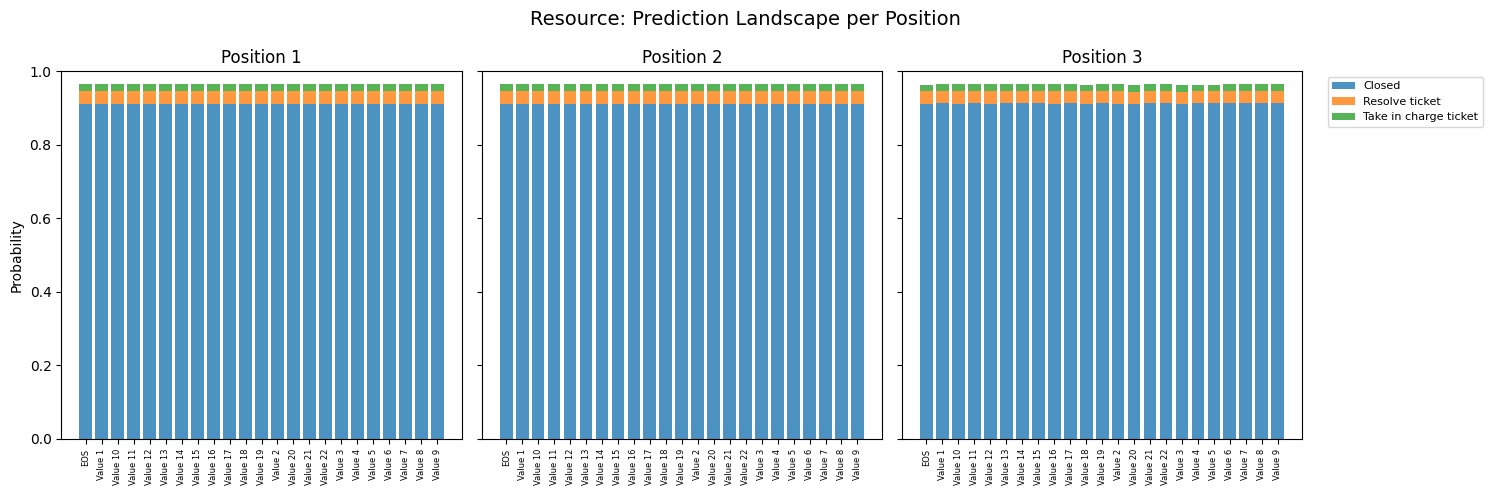

In [9]:
# For each event-level mutable feature, one figure with subplots per position
event_level_features = [ci for ci in MUTABLE_CAT_INDICES if ci not in CASE_LEVEL_CAT_INDICES]

# Get top-5 most common predicted classes across all sweep results for readable legends
top_classes = df_sweep['predicted_class'].value_counts().head(5).index.tolist()
if original_pred_idx not in top_classes:
    top_classes = [original_pred_idx] + top_classes[:4]

for ci in event_level_features:
    feat_name = decoder.cat_features[ci]
    df_feat = df_sweep[df_sweep['feature_idx'] == ci].copy()

    fig, axes = plt.subplots(1, prefix_len, figsize=(5 * prefix_len, 5), sharey=True)
    if prefix_len == 1:
        axes = [axes]

    for pos_idx in range(prefix_len):
        ax = axes[pos_idx]
        df_pos = df_feat[df_feat['position'] == pos_idx + 1].sort_values('value_idx')

        # Stacked bar: for each value, show probability of top classes
        prob_data = {}
        for cls_idx in top_classes:
            cls_name = activity_names[cls_idx]
            probs = [row['probability_vector'][cls_idx] for _, row in df_pos.iterrows()]
            prob_data[cls_name] = probs

        x = range(len(df_pos))
        bottom = np.zeros(len(df_pos))
        for cls_name, probs in prob_data.items():
            ax.bar(x, probs, bottom=bottom, label=cls_name, alpha=0.8, width=0.8)
            bottom += np.array(probs)

        ax.set_xticks(list(x))
        ax.set_xticklabels(df_pos['value_name'].tolist(), rotation=90, fontsize=6)
        ax.set_title(f'Position {pos_idx + 1}')
        ax.set_ylim(0, 1)
        if pos_idx == 0:
            ax.set_ylabel('Probability')

    axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    fig.suptitle(f'{feat_name}: Prediction Landscape per Position', fontsize=14)
    plt.tight_layout()
    plt.show()